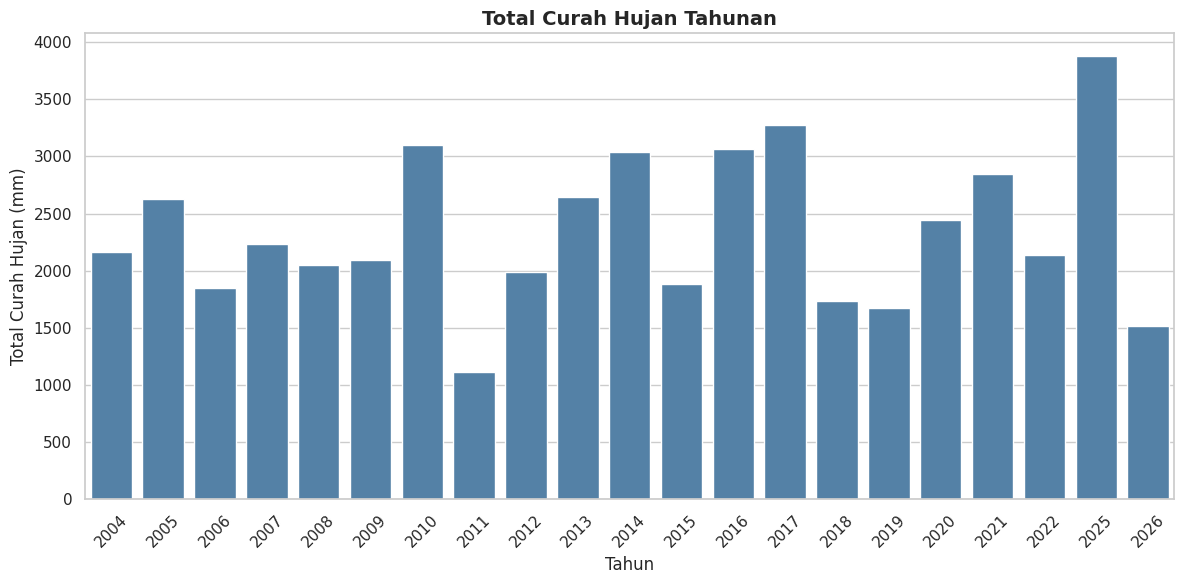

/tmp/ipykernel_2515/3658078967.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg, x='Bulan', y='Curah Hujan (mm)', palette='Blues_r')


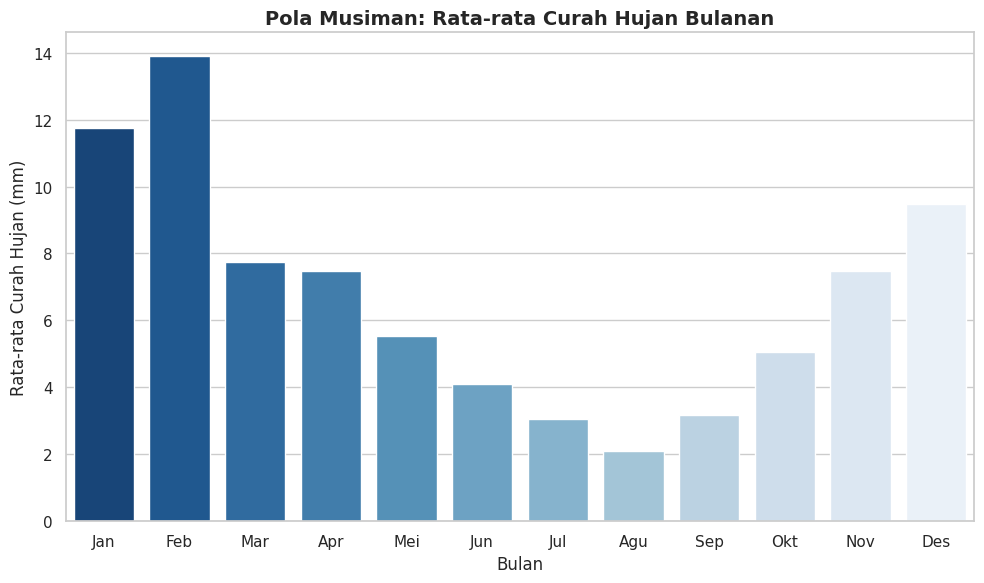

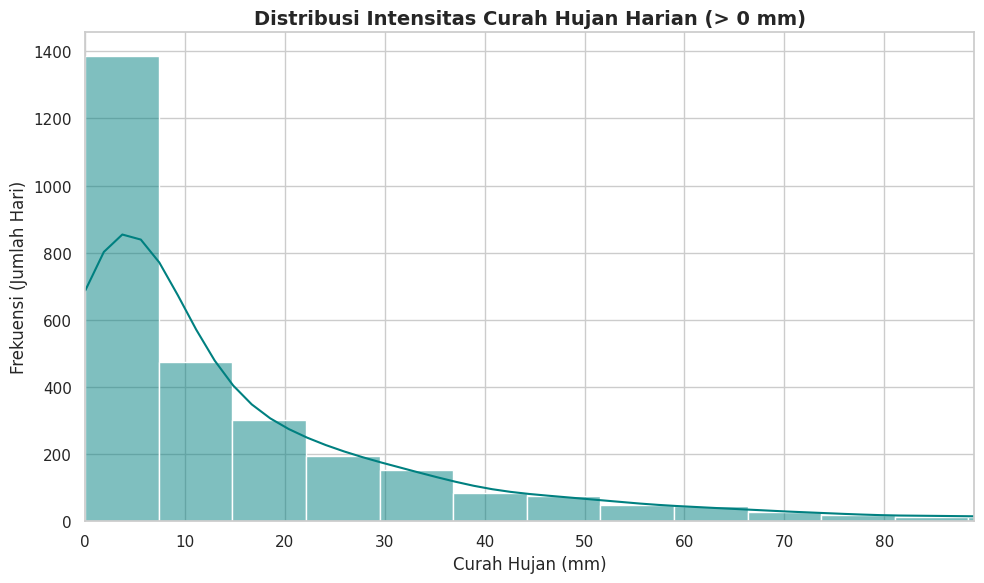

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
# Gunakan sep=';' karena file disiapkan dengan format titik koma
df = pd.read_csv('Curah_Hujan.csv', sep=';')

# Ubah tipe data kolom Tanggal menjadi datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# Ekstrak Tahun dan Bulan untuk pengelompokan
df['Tahun'] = df['Tanggal'].dt.year
df['Bulan'] = df['Tanggal'].dt.month

# Atur gaya grafik (bisa diganti sesuai selera, misal 'darkgrid' atau 'ticks')
sns.set_theme(style="whitegrid")


# ==========================================
# GRAFIK 1: Total Curah Hujan per Tahun
# ==========================================
yearly_rainfall = df.groupby('Tahun')['Curah Hujan (mm)'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_rainfall, x='Tahun', y='Curah Hujan (mm)', color='steelblue')
plt.title('Total Curah Hujan Tahunan', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Curah Hujan (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ==========================================
# GRAFIK 2: Rata-rata Curah Hujan Bulanan
# ==========================================
monthly_avg = df.groupby('Bulan')['Curah Hujan (mm)'].mean().reset_index()

# Ubah angka bulan jadi nama bulan biar lebih rapi
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
monthly_avg['Bulan'] = monthly_avg['Bulan'].apply(lambda x: month_names[x-1])

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_avg, x='Bulan', y='Curah Hujan (mm)', palette='Blues_r')
plt.title('Pola Musiman: Rata-rata Curah Hujan Bulanan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata Curah Hujan (mm)', fontsize=12)
plt.tight_layout()
plt.show()


# ==========================================
# GRAFIK 3: Distribusi Curah Hujan Harian
# ==========================================
# Kita buang hari yang cerah/kering (0 mm) agar grafik distribusinya tidak timpang
rainy_days = df[df['Curah Hujan (mm)'] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(rainy_days['Curah Hujan (mm)'], bins=50, kde=True, color='teal')
plt.title('Distribusi Intensitas Curah Hujan Harian (> 0 mm)', fontsize=14, fontweight='bold')
plt.xlabel('Curah Hujan (mm)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Hari)', fontsize=12)

# Batasi sumbu X (misal ambil sampai persentil 98) agar pencilan (outlier) ekstrem tidak membuat grafik terlalu lebar
plt.xlim(0, rainy_days['Curah Hujan (mm)'].quantile(0.98))
plt.tight_layout()
plt.show()

/tmp/ipykernel_2515/1114487453.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=kategori_counts, x='Kategori Hujan', y='Jumlah Hari', palette='viridis')


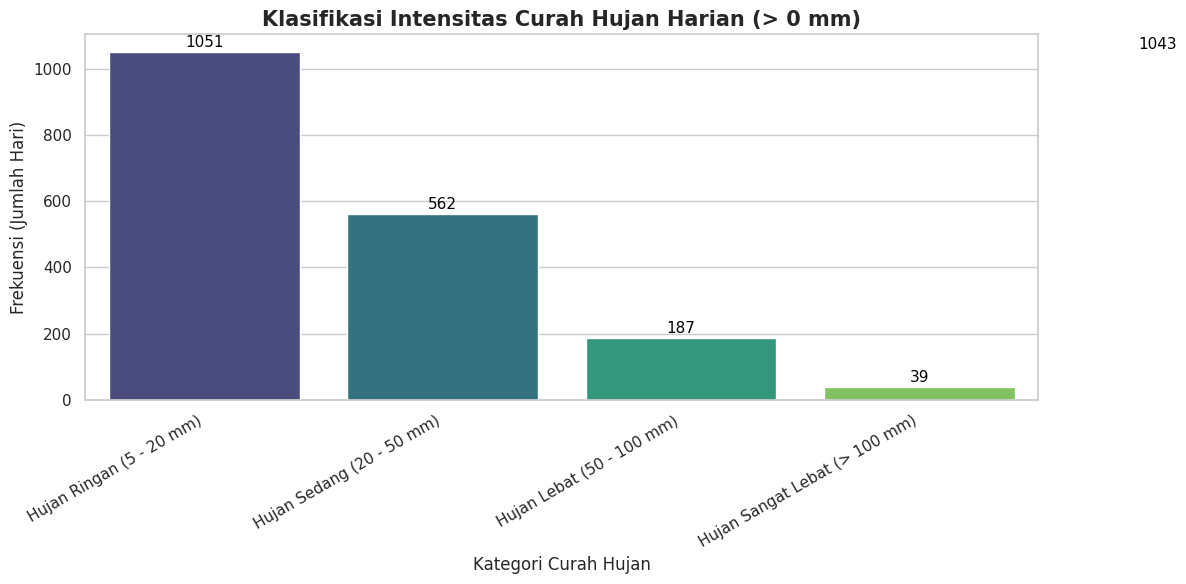

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Baca data
df = pd.read_csv('Curah_Hujan.csv', sep=';')

# 2. Buat fungsi klasifikasi berdasarkan standar yang diminta
def klasifikasi_hujan(ch):
    if pd.isna(ch):
        return np.nan
    elif ch == 0.0:
        return 'Tidak Hujan (0 mm)'
    elif 5 <= ch <= 20:
        return 'Hujan Ringan (5 - 20 mm)'
    elif 20 < ch <= 50:
        return 'Hujan Sedang (20 - 50 mm)'
    elif 50 < ch <= 100:
        return 'Hujan Lebat (50 - 100 mm)'
    elif ch > 100:
        return 'Hujan Sangat Lebat (> 100 mm)'
    else:
        return 'Tidak Terdefinisi'

# 3. Terapkan (apply) fungsi tersebut ke kolom Curah Hujan
df['Kategori Hujan'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)

# (Opsional) Simpan ke file CSV baru
# df.to_csv('Curah_Hujan_Terklasifikasi.csv', index=False, sep=';')

# ==========================================
# GRAFIK DISTRIBUSI KELAS CURAH HUJAN
# ==========================================

# FILTER: Hanya ambil data yang nilai curah hujannya di atas 0
df_hujan = df[df['Curah Hujan (mm)'] > 0]

# Hitung total hari untuk masing-masing kategori (dari data yang sudah difilter)
kategori_counts = df_hujan['Kategori Hujan'].value_counts().reset_index()
kategori_counts.columns = ['Kategori Hujan', 'Jumlah Hari']

# Atur urutan kategori (Kelas 'Tidak Hujan' sudah dihapus dari daftar)
urutan = [
    'Hujan Ringan (5 - 20 mm)',
    'Hujan Sedang (20 - 50 mm)',
    'Hujan Lebat (50 - 100 mm)',
    'Hujan Sangat Lebat (> 100 mm)'
]

# Ubah tipe data kolom kategori menjadi Categorical agar urutannya mengunci
kategori_counts['Kategori Hujan'] = pd.Categorical(
    kategori_counts['Kategori Hujan'],
    categories=urutan,
    ordered=True
)
kategori_counts = kategori_counts.sort_values('Kategori Hujan')

# Set visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Buat bar chart
ax = sns.barplot(data=kategori_counts, x='Kategori Hujan', y='Jumlah Hari', palette='viridis')

plt.title('Klasifikasi Intensitas Curah Hujan Harian (> 0 mm)', fontsize=15, fontweight='bold')
plt.xlabel('Kategori Curah Hujan', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Hari)', fontsize=12)
plt.xticks(rotation=30, ha='right') # Putar tulisan di sumbu X agar tidak saling tabrak

# Tambahkan angka (label) tepat di atas setiap bar/batang
# Angka penambah (+ 15) disesuaikan agar teks tidak terlalu jauh dari puncak bar
for index, row in enumerate(kategori_counts['Jumlah Hari']):
    plt.text(index, row + 15, str(row), color='black', ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. PERSIAPAN DATA
# ==========================================
df = pd.read_csv('Curah_Hujan.csv', sep=';')

def klasifikasi_hujan(ch):
    if pd.isna(ch): return np.nan
    elif ch < 5: return 'Ringan/Tidak Hujan (< 5 mm)'
    elif 5 <= ch <= 20: return 'Hujan Ringan (5 - 20 mm)'
    elif 20 < ch <= 50: return 'Hujan Sedang (20 - 50 mm)'
    elif 50 < ch <= 100: return 'Hujan Lebat (50 - 100 mm)'
    else: return 'Hujan Sangat Lebat (> 100 mm)'

df['Kategori'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)
df = df.dropna()

label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Kategori'])

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

# ==========================================
# 2. SEQUENCE (Diubah jadi 14 Hari)
# ==========================================
# 14 hari ke belakang terbukti lebih optimal untuk tren cuaca lokal
time_steps = 14

X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. CLASS WEIGHTS (Dengan Softening)
# ==========================================
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)

# TRIK RAHASIA: Pelembutan bobot menggunakan akar kuadrat
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

print("\nBobot kelas setelah dilembutkan:")
for k, v in class_weights_dict.items():
    print(f"Kelas {label_encoder.inverse_transform([k])[0]}: {v:.2f}")

# ==========================================
# 4. ARSITEKTUR LSTM & OPTIMIZER CLIP
# ==========================================
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=len(kelas_unik), activation='softmax'))

# TRIK RAHASIA 2: Gradient Clipping (clipvalue=1.0) agar tidak meledak
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 5. CALLBACKS & TRAINING
# ==========================================
class TargetAkurasiCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        target_akurasi = 0.75
        akurasi_saat_ini = logs.get('val_accuracy')
        if akurasi_saat_ini is not None and akurasi_saat_ini >= target_akurasi:
            print(f"\n[INFO] Target tercapai! Akurasi validasi: {akurasi_saat_ini:.4f}")
            self.model.stop_training = True

callback_akurasi = TargetAkurasiCallback()
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True, verbose=1)

print("\nMulai proses training (Maksimal 400 Epochs)...")
history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[callback_akurasi, reduce_lr, early_stop],
    verbose=1
)


Bobot kelas setelah dilembutkan:
Kelas Hujan Lebat (50 - 100 mm): 2.97
Kelas Hujan Ringan (5 - 20 mm): 1.21
Kelas Hujan Sangat Lebat (> 100 mm): 6.47
Kelas Hujan Sedang (20 - 50 mm): 1.64
Kelas Ringan/Tidak Hujan (< 5 mm): 0.51

Mulai proses training (Maksimal 400 Epochs)...
Epoch 1/400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7573 - loss: 1.0462 - val_accuracy: 0.6983 - val_loss: 1.0099 - learning_rate: 0.0010
Epoch 2/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7621 - loss: 1.0170 - val_accuracy: 0.6983 - val_loss: 1.0744 - learning_rate: 0.0010
Epoch 3/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7589 - loss: 1.0045 - val_accuracy: 0.6928 - val_loss: 1.0263 - learning_rate: 0.0010
Epoch 4/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7592 - loss: 0.9949 - val_accuracy: 0.6983 - val_loss: 1.0016 - learning_rate: 0.0010
Epoch 5/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7604 - loss: 0.9949 - val_accuracy: 0.6983 - val_loss: 1.0160 - learning_rate: 0.0010
Epoch 6/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7616 - loss: 0.9937 - val_accuracy: 0.6928 - val_loss: 0.9897 - learning_rate: 0.0010
Epoch 7/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7580 - loss: 0.9876 

**LSTM REGRESI**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber

# ==========================================
# 1. PERSIAPAN DATA (MURNI ANGKA MM)
# ==========================================
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

# Scaling (Wajib untuk LSTM agar angkanya berada di range 0-1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['Curah Hujan (mm)']])

# ==========================================
# 2. MEMBUAT SEQUENCE (14 Hari ke Belakang)
# ==========================================
time_steps = 14
X, y = [], []

for i in range(len(data_scaled) - time_steps):
    X.append(data_scaled[i : i + time_steps])
    y.append(data_scaled[i + time_steps, 0]) # Target adalah angka curah hujan di hari ke-15

X, y = np.array(X), np.array(y)

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. ARSITEKTUR LSTM (REGRESI)
# ==========================================
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=16, activation='relu'))

# KUNCI REGRESI: Hanya 1 Neuron di output, aktivasi ReLU (karena curah hujan tidak bisa minus)
model.add(Dense(units=1, activation='relu'))

# KUNCI REGRESI 2: Menggunakan Huber Loss yang tahan banting terhadap anomali cuaca ekstrem
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])

# ==========================================
# 4. TRAINING
# ==========================================
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)

print("\nMulai proses training Regresi LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# ==========================================
# 5. EVALUASI & KONVERSI KEMBALI KE KELAS
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred_scaled = model.predict(X_test)

# Kembalikan skala dari (0-1) menjadi skala asli (Milimeter)
y_pred_mm = scaler.inverse_transform(y_pred_scaled)
y_test_mm = scaler.inverse_transform(y_test.reshape(-1, 1))

# Fungsi Klasifikasi berdasarkan rentang angka (Sesuai BMKG)
def klasifikasi_hujan(ch):
    if ch < 5: return '0_Cerah/Sangat Ringan (<5)'
    elif 5 <= ch <= 20: return '1_Ringan (5-20)'
    elif 20 < ch <= 50: return '2_Sedang (20-50)'
    elif 50 < ch <= 100: return '3_Lebat (50-100)'
    else: return '4_Sangat Lebat (>100)'

# Membuat DataFrame hasil untuk membandingkan Aktual vs Prediksi
df_hasil = pd.DataFrame({
    'Aktual (mm)': y_test_mm.flatten(),
    'Prediksi (mm)': y_pred_mm.flatten()
})

# Terapkan klasifikasi pada hasil regresi
df_hasil['Kelas Aktual'] = df_hasil['Aktual (mm)'].apply(klasifikasi_hujan)
df_hasil['Kelas Prediksi'] = df_hasil['Prediksi (mm)'].apply(klasifikasi_hujan)

print("\n=======================================================")
print("  HASIL EVALUASI AKHIR (DARI REGRESI KE KLASIFIKASI)   ")
print("=======================================================")
print(classification_report(df_hasil['Kelas Aktual'], df_hasil['Kelas Prediksi'], zero_division=0))

# Menampilkan 10 tebakan angka acak untuk perbandingan visual
print("\nContoh Perbandingan Angka Aktual vs Prediksi:")
print(df_hasil.sample(10, random_state=42))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Mulai proses training Regresi LSTM...
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0011 - mae: 0.0208 - val_loss: 0.0016 - val_mae: 0.0306 - learning_rate: 0.0010
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0011 - mae: 0.0241 - val_loss: 0.0018 - val_mae: 0.0232 - learning_rate: 0.0010
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0011 - mae: 0.0234 - val_loss: 0.0016 - val_mae: 0.0298 - learning_rate: 0.0010
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0011 - mae: 0.0238 - val_loss: 0.0016 - val_mae: 0.0322 - learning_rate: 0.0010
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0010 - mae: 0.0240 - val_loss: 0.0016 - val_mae: 0.0273 - learning_rate: 0.0010
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0010 - mae: 0.0237 - val_loss: 0.0016 - val_mae: 0.0300 - learning_rate: 0.0010
Epoch 7/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0010 - mae: 0.0238 - val_loss: 0.

**XGBOOST**

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

# ==========================================
# 1. PERSIAPAN DATA & FEATURE ENGINEERING
# ==========================================
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

# Fungsi klasifikasi sesuai standar BMKG
def klasifikasi_hujan(ch):
    if ch < 5: return 0           # 0: Cerah/Sangat Ringan
    elif 5 <= ch <= 20: return 1  # 1: Ringan
    elif 20 < ch <= 50: return 2  # 2: Sedang
    elif 50 < ch <= 100: return 3 # 3: Lebat
    else: return 4                # 4: Sangat Lebat

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)

# Mengubah data Time-Series menjadi Tabular (Membuat Lag Features)
# Kita jadikan riwayat hujan 14 hari ke belakang sebagai "kolom fitur"
time_steps = 14
for i in range(1, time_steps + 1):
    df[f'Hujan_H-{i}'] = df['Curah Hujan (mm)'].shift(i)

# Hapus baris pertama (14 hari) yang memiliki nilai kosong akibat proses shifting
df = df.dropna()

# ==========================================
# 2. MENENTUKAN FITUR (X) DAN TARGET (y)
# ==========================================
fitur_kolom = [f'Hujan_H-{i}' for i in range(1, time_steps + 1)]
X = df[fitur_kolom].values
y = df['Label'].astype(int).values

# Split Data (80% Train, 20% Test)
# Penting: shuffle=False agar urutan waktu (time-series) tidak berantakan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. PENANGANAN IMBALANCED DATA UNTUK XGBOOST
# ==========================================
# Secara otomatis menghitung dan memberikan bobot besar pada hari hujan lebat
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ==========================================
# 4. MEMBANGUN DAN MELATIH MODEL XGBOOST
# ==========================================
print("Mulai melatih model XGBoost...")
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    max_depth=6,              # Kedalaman pohon keputusan
    learning_rate=0.05,       # Kecepatan belajar
    n_estimators=300,         # Jumlah pohon
    subsample=0.8,            # Mengambil 80% data acak tiap iterasi untuk cegah overfit
    colsample_bytree=0.8,     # Mengambil 80% fitur acak
    random_state=42
)

# Latih model dengan memasukkan bobot penyeimbang
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# ==========================================
# 5. EVALUASI MODEL
# ==========================================
print("Melakukan Prediksi pada Data Test...\n")
y_pred = xgb_model.predict(X_test)

nama_kelas = [
    '0_Cerah/Sangat Ringan (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat (50-100)',
    '4_Sangat Lebat (>100)'
]

print("=======================================================")
print("          HASIL EVALUASI AKHIR MODEL XGBOOST           ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print("Detail Performa per Kelas:")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

Mulai melatih model XGBoost...
Melakukan Prediksi pada Data Test...

          HASIL EVALUASI AKHIR MODEL XGBOOST           
Akurasi Keseluruhan: 0.5331

Detail Performa per Kelas:
                            precision    recall  f1-score   support

0_Cerah/Sangat Ringan (<5)       0.73      0.69      0.71      1023
           1_Ringan (5-20)       0.20      0.24      0.22       252
          2_Sedang (20-50)       0.08      0.10      0.09       126
          3_Lebat (50-100)       0.04      0.02      0.03        53
     4_Sangat Lebat (>100)       0.00      0.00      0.00        11

                  accuracy                           0.53      1465
                 macro avg       0.21      0.21      0.21      1465
              weighted avg       0.55      0.53      0.54      1465



In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
import xgboost as xgb

# 1. Definisikan LSTM sebagai Feature Extractor
inputs = Input(shape=(14, 1))
x = LSTM(64, return_sequences=False)(inputs)
x = Dense(16, activation='relu')(x) # Layer ini adalah 'ringkasan' pola dari LSTM
feature_extractor = Model(inputs=inputs, outputs=x)

# 2. Ekstraksi fitur dari LSTM
X_train_lstm_features = feature_extractor.predict(X_train)
X_test_lstm_features = feature_extractor.predict(X_test)

# 3. Masukkan ke XGBoost
# Gabungkan fitur dari LSTM dengan fitur asli (lagged features) jika perlu
xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05)
xgb_model.fit(X_train_lstm_features, y_train)

# 4. Prediksi
y_pred = xgb_model.predict(X_test_lstm_features)

183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


**HYBRID LSTM + XGBOOST**

In [ ]:
# @title
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI)
# ==========================================
print("Memuat dan memproses data...")
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

def klasifikasi_hujan(ch):
    if ch < 5: return 0
    elif 5 <= ch <= 20: return 1
    elif 20 < ch <= 50: return 2
    elif 50 < ch <= 100: return 3
    else: return 4

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

time_steps = 14
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# ==========================================
# 2. TAHAP 1: MELATIH LSTM (FUNCTIONAL API)
# ==========================================
print("\n--- TAHAP 1: Melatih Model LSTM ---")

kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# MENGGUNAKAN FUNCTIONAL API (Anti Error Saat Dipotong)
input_layer = Input(shape=(X_train.shape[1], 1), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# LAYER KUNCI: Layer feature extraction
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)

# Output Klasifikasi
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(feature_layer)

# Menyatukan input dan output ke dalam satu entitas Model
model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Selesai melatih LSTM (Tahap 1).")


# ==========================================
# 3. EKSTRAKSI FITUR DARI OTAK LSTM
# ==========================================
print("\nMengekstrak fitur vektor dari lapisan tersembunyi LSTM...")
# Pemotongan sekarang dijamin berhasil 100%
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)


# ==========================================
# 4. TAHAP 2: MELATIH XGBOOST MENGGUNAKAN FITUR HYBRID
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost dengan Fitur dari LSTM ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(kelas_unik),
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Selesai melatih XGBoost (Tahap 2).")


# ==========================================
# 5. EVALUASI AKHIR MODEL HYBRID
# ==========================================
print("\nMelakukan Prediksi Hybrid pada Data Test...")
y_pred_hybrid = xgb_model.predict(X_test_features)

nama_kelas = [
    '0_Cerah (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat (50-100)',
    '4_Sangat Lebat (>100)'
]

print("\n=======================================================")
print("     HASIL EVALUASI MODEL HYBRID (LSTM + XGBOOST)      ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=nama_kelas, zero_division=0))

Memuat dan memproses data...

--- TAHAP 1: Melatih Model LSTM ---
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7497 - loss: 1.0379 - val_accuracy: 0.6983 - val_loss: 1.0485 - learning_rate: 0.0010
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7606 - loss: 1.0172 - val_accuracy: 0.6983 - val_loss: 0.9891 - learning_rate: 0.0010
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7584 - loss: 1.0011 - val_accuracy: 0.6833 - val_loss: 1.0360 - learning_rate: 0.0010
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7524 - loss: 0.9936 - val_accuracy: 0.6867 - val_loss: 1.0158 - learning_rate: 0.0010
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7486 - loss: 0.9841 - val_accuracy: 0.6683 - val_loss: 1.0239 - learning_rate: 0.0010
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7532 - loss: 0.9825 - val_accuracy: 0.6724 - val_loss: 1.0555 - learning_rate: 0.0010
Epoch 7/2

In [ ]:
# @title
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI)
# ==========================================
print("Memuat dan memproses data...")
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

def klasifikasi_hujan(ch):
    if ch < 5: return 0
    elif 5 <= ch <= 20: return 1
    elif 20 < ch <= 50: return 2
    elif 50 < ch <= 100: return 3
    else: return 4

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

time_steps = 14
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# ==========================================
# 2. TAHAP 1: MELATIH LSTM (FUNCTIONAL API)
# ==========================================
print("\n--- TAHAP 1: Melatih Model LSTM ---")

kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# MENGGUNAKAN FUNCTIONAL API (Anti Error Saat Dipotong)
input_layer = Input(shape=(X_train.shape[1], 1), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# LAYER KUNCI: Layer feature extraction
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)

# Output Klasifikasi
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(feature_layer)

# Menyatukan input dan output ke dalam satu entitas Model
model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Selesai melatih LSTM (Tahap 1).")


# ==========================================
# 3. EKSTRAKSI FITUR DARI OTAK LSTM
# ==========================================
print("\nMengekstrak fitur vektor dari lapisan tersembunyi LSTM...")
# Pemotongan sekarang dijamin berhasil 100%
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)


# ==========================================
# 4. TAHAP 2: MELATIH XGBOOST MENGGUNAKAN FITUR HYBRID
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost dengan Fitur dari LSTM ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(kelas_unik),
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Selesai melatih XGBoost (Tahap 2).")


# ==========================================
# 5. EVALUASI AKHIR MODEL HYBRID
# ==========================================
print("\nMelakukan Prediksi Hybrid pada Data Test...")
y_pred_hybrid = xgb_model.predict(X_test_features)

nama_kelas = [
    '0_Cerah (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat (50-100)',
    '4_Sangat Lebat (>100)'
]

print("\n=======================================================")
print("     HASIL EVALUASI MODEL HYBRID (LSTM + XGBOOST)      ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=nama_kelas, zero_division=0))

Memuat dan memproses data...

--- TAHAP 1: Melatih Model LSTM ---
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7580 - loss: 1.0506 - val_accuracy: 0.6983 - val_loss: 1.0401 - learning_rate: 0.0010
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7621 - loss: 1.0173 - val_accuracy: 0.6983 - val_loss: 0.9866 - learning_rate: 0.0010
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7601 - loss: 1.0062 - val_accuracy: 0.6915 - val_loss: 1.1124 - learning_rate: 0.0010
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7592 - loss: 0.9971 - val_accuracy: 0.6983 - val_loss: 1.0070 - learning_rate: 0.0010
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7613 - loss: 0.9951 - val_accuracy: 0.6983 - val_loss: 1.0595 - learning_rate: 0.0010
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7611 - loss: 0.9957 - val_accuracy: 0.6983 - val_loss: 1.0592 - learning_rate: 0.0010
Epoch 7/2

**HYBRID BINER**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI BINER)
# ==========================================
print("Memuat dan memproses data untuk Klasifikasi Biner...")
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

# FUNGSI KLASIFIKASI BARU: Disederhanakan menjadi 2 Kelas
def klasifikasi_hujan_biner(ch):
    if ch < 50: return 0  # 0: Aman (Cerah atau Hujan Biasa < 50 mm)
    else: return 1        # 1: Waspada Banjir (Hujan Lebat/Sangat Lebat >= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_biner)

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

time_steps = 14
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. TAHAP 1: MELATIH LSTM (FEATURE EXTRACTOR BINER)
# ==========================================
print("\n--- TAHAP 1: Melatih Model LSTM ---")

kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

input_layer = Input(shape=(X_train.shape[1], 1), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# Layer feature extraction (Tetap menggunakan 16 fitur jembatan)
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)

# Output menyesuaikan jumlah kelas yang sekarang cuma ada 2
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Selesai melatih LSTM (Tahap 1).")

# ==========================================
# 3. EKSTRAKSI FITUR DARI OTAK LSTM
# ==========================================
print("\nMengekstrak fitur vektor dari lapisan tersembunyi LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 4. TAHAP 2: MELATIH XGBOOST UNTUK KLASIFIKASI BINER
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost dengan Fitur Hybrid Biner ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# XGBoost secara otomatis akan menyesuaikan menjadi klasifikasi biner
xgb_model = xgb.XGBClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Selesai melatih XGBoost (Tahap 2).")

# ==========================================
# 5. EVALUASI AKHIR MODEL HYBRID BINER
# ==========================================
print("\nMelakukan Prediksi Biner pada Data Test...")
y_pred_hybrid = xgb_model.predict(X_test_features)

nama_kelas_biner = [
    '0_Aman (<50 mm)',
    '1_Waspada Banjir (>=50 mm)'
]

print("\n=======================================================")
print("  HASIL EVALUASI MODEL HYBRID (KLASIFIKASI BINER)      ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=nama_kelas_biner, zero_division=0))

Memuat dan memproses data untuk Klasifikasi Biner...

--- TAHAP 1: Melatih Model LSTM ---
Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.9718 - loss: 0.3673 - val_accuracy: 0.9556 - val_loss: 0.1880 - learning_rate: 0.0010
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9718 - loss: 0.3458 - val_accuracy: 0.9556 - val_loss: 0.2230 - learning_rate: 0.0010
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9718 - loss: 0.3413 - val_accuracy: 0.9556 - val_loss: 0.2154 - learning_rate: 0.0010
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9718 - loss: 0.3440 - val_accuracy: 0.9556 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9718 - loss: 0.3392 - val_accuracy: 0.9556 - val_loss: 0.2475 - learning_rate: 0.0010
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9704 - loss: 0.3513
Epoch 6: ReduceLROnPlateau reducing learning rate t

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI BINER)
# ==========================================
print("Memuat dan memproses data...")
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

# Target disederhanakan: Waspada jika hujan >= 50mm
def klasifikasi_hujan_biner(ch):
    if ch < 50: return 0  # 0: Aman (<50 mm)
    else: return 1        # 1: Waspada Banjir (>=50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_biner)

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

time_steps = 14
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. MENGHITUNG BOBOT (CLASS WEIGHTS)
# ==========================================
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
# Tetap dilembutkan dengan akar kuadrat agar penaltinya tidak meledak
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# ==========================================
# 3. MEMBANGUN ARSITEKTUR LSTM BINER
# ==========================================
print("\n--- Membangun dan Melatih Model LSTM Biner ---")
model_lstm = Sequential()
model_lstm.add(Input(shape=(X_train.shape[1], 1)))

model_lstm.add(LSTM(units=64, return_sequences=True))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=32, return_sequences=False))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(units=16, activation='relu'))

# KUNCI BINER: 1 Unit output dengan aktivasi Sigmoid
model_lstm.add(Dense(units=1, activation='sigmoid'))

# KUNCI BINER: Loss menggunakan binary_crossentropy
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# ==========================================
# 4. TRAINING MODEL
# ==========================================
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 5. EVALUASI MODEL
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
# Prediksi sigmoid menghasilkan angka probabilitas (0.0 sampai 1.0)
y_pred_prob = model_lstm.predict(X_test)

# Jika probabilitas > 0.5 (50%), maka masuk kelas 1 (Waspada), selain itu 0 (Aman)
y_pred_biner = (y_pred_prob > 0.5).astype(int).flatten()

nama_kelas_biner = ['0_Aman (<50 mm)', '1_Waspada Banjir (>=50 mm)']

print("\n=======================================================")
print("  HASIL EVALUASI LSTM MURNI (KLASIFIKASI BINER)        ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_biner):.4f}\n")
print(classification_report(y_test, y_pred_biner, target_names=nama_kelas_biner, zero_division=0))

Memuat dan memproses data...

--- Membangun dan Melatih Model LSTM Biner ---
Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9718 - loss: 0.3717 - val_accuracy: 0.9556 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9718 - loss: 0.3411 - val_accuracy: 0.9556 - val_loss: 0.2643 - learning_rate: 0.0010
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9718 - loss: 0.3439 - val_accuracy: 0.9556 - val_loss: 0.2646 - learning_rate: 0.0010
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9718 - loss: 0.3424 - val_accuracy: 0.9556 - val_loss: 0.2656 - learning_rate: 0.0010
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9718 - loss: 0.3429 - val_accuracy: 0.9556 - val_loss: 0.2401 - learning_rate: 0.0010
Epoch 6/100
180/183 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9748 - loss: 0.3142
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.000500000

In [ ]:
import pandas as pd
import requests

# 1. Baca data curah hujan yang sudah Anda miliki
print("Membaca data curah hujan...")
df_hujan = pd.read_csv('Curah_Hujan.csv', sep=';')
df_hujan['Tanggal'] = pd.to_datetime(df_hujan['Tanggal'])

# Ambil rentang tanggal secara dinamis dari data Anda
start_date = df_hujan['Tanggal'].min().strftime('%Y-%m-%d')
end_date = df_hujan['Tanggal'].max().strftime('%Y-%m-%d')

print(f"Mengunduh data iklim Jakarta dari {start_date} hingga {end_date}...")

# 2. Ambil data pendukung dari API Open-Meteo (Gratis)
# Titik koordinat disetel untuk area Jakarta Raya
lat, lon = -6.2088, 106.8456

url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max&timezone=Asia%2FJakarta"

response = requests.get(url)
data = response.json()

# 3. Ekstrak JSON menjadi DataFrame Pandas
print("Memproses data hasil unduhan...")
df_iklim = pd.DataFrame({
    'Tanggal': pd.to_datetime(data['daily']['time']),
    'Suhu Rata-rata (C)': data['daily']['temperature_2m_mean'],
    'Kelembapan Rata-rata (%)': data['daily']['relative_humidity_2m_mean'],
    'Kecepatan Angin Max (km/h)': data['daily']['wind_speed_10m_max']
})

# 4. Gabungkan (Merge) dengan data curah hujan historis Anda
df_final = pd.merge(df_hujan, df_iklim, on='Tanggal', how='inner')

# Jika ada 1 atau 2 hari yang datanya kosong dari server, kita isi otomatis (interpolasi)
df_final = df_final.interpolate(method='linear')

# 5. Simpan sebagai file CSV baru
nama_file_baru = 'Data_Multivariat_Jakarta_Siap.csv'
df_final.to_csv(nama_file_baru, index=False, sep=';')

print(f"\nSelesai! Data berhasil digabung dan disimpan sebagai '{nama_file_baru}'")

# Tampilkan 5 baris pertama untuk dicek
display(df_final.head())

Membaca data curah hujan...
Mengunduh data iklim Jakarta dari 2004-01-01 hingga 2026-03-31...
Memproses data hasil unduhan...

Selesai! Data berhasil digabung dan disimpan sebagai 'Data_Multivariat_Jakarta_Siap.csv'


,Tanggal,Curah Hujan (mm),Suhu Rata-rata (C),Kelembapan Rata-rata (%),Kecepatan Angin Max (km/h)
0,2004-01-01,0.5,25.9,85,16.3
1,2004-01-02,0.0,26.5,82,16.6
2,2004-01-03,5.2,26.2,85,15.0
3,2004-01-04,1.5,25.8,86,13.6
4,2004-01-05,70.0,25.9,83,14.5


**LSTM DATA MULTIVARIAT**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. PERSIAPAN DATA MULTIVARIAT (4 KELAS)
# ==========================================
print("Memuat dan memproses data Iklim Multivariat...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df = df.dropna() # Pastikan tidak ada data kosong

# FUNGSI KLASIFIKASI BARU: Disederhanakan menjadi 4 Kelas
def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return 0           # 0: Cerah / Sangat Ringan
    elif 5 <= ch <= 20: return 1  # 1: Ringan
    elif 20 < ch <= 50: return 2  # 2: Sedang
    else: return 3                # 3: Lebat & Ekstrem (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

# Normalisasi SEMUA fitur iklim (Hujan, Suhu, Kelembapan, Angin)
fitur_iklim = [
    'Curah Hujan (mm)',
    'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)',
    'Kecepatan Angin Max (km/h)'
]

scaler = MinMaxScaler(feature_range=(0, 1))
# Menyimpan hasil scaling kembali ke dataframe baru
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_iklim]), columns=fitur_iklim)

# ==========================================
# 2. MEMBUAT SEQUENCE (DATA RUNTUN WAKTU)
# ==========================================
time_steps = 14
X, y = [], []

# X sekarang akan mengambil 4 kolom sekaligus
for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)

# Bentuk X sekarang adalah (Jumlah Sampel, 14 Hari, 4 Fitur)
print(f"Bentuk input data X: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. MENGHITUNG BOBOT (CLASS WEIGHTS)
# ==========================================
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
# Pelembutan bobot agar terhindar dari gradient explosion
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# ==========================================
# 4. MEMBANGUN ARSITEKTUR LSTM MULTIVARIAT
# ==========================================
print("\n--- Membangun dan Melatih Model LSTM ---")

# Input layer menyesuaikan dengan fitur yang baru (14, 4)
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)
x = Dense(units=16, activation='relu')(x)

# Output menggunakan 4 neuron sesuai dengan jumlah kelas
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(x)

model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 5. TRAINING MODEL (EPOCH 400, PATIENCE 70)
# ==========================================
# Rem otomatis jika 15 epoch jalan di tempat
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00001, verbose=1)

# Tombol stop darurat (Patience 70 sesuai permintaan)
early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=400,         # <--- Diatur menjadi 400 Epoch
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 6. EVALUASI AKHIR MODEL
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")

# Model memprediksi probabilitas untuk setiap kelas
y_pred_prob = model_lstm.predict(X_test)
# Kita ambil kelas dengan probabilitas tertinggi
y_pred = np.argmax(y_pred_prob, axis=1)

nama_kelas = [
    '0_Cerah (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat/Ekstrem (>=50)'
]

print("\n=======================================================")
print("  HASIL EVALUASI LSTM MULTIVARIAT (4 KELAS)            ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

Memuat dan memproses data Iklim Multivariat...
Bentuk input data X: (7321, 14, 4)

--- Membangun dan Melatih Model LSTM ---
Epoch 1/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7502 - loss: 1.0015 - val_accuracy: 0.6983 - val_loss: 0.9466 - learning_rate: 0.0010
Epoch 2/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7544 - loss: 0.9689 - val_accuracy: 0.6983 - val_loss: 1.0474 - learning_rate: 0.0010
Epoch 3/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7582 - loss: 0.9671 - val_accuracy: 0.6983 - val_loss: 0.9890 - learning_rate: 0.0010
Epoch 4/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7587 - loss: 0.9614 - val_accuracy: 0.6751 - val_loss: 1.0111 - learning_rate: 0.0010
Epoch 5/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7517 - loss: 0.9607 - val_accuracy: 0.6997 - val_loss: 0.9795 - learning_rate: 0.0010
Epoch 6/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7493 - loss: 0.9543 - val_accuracy: 0.6826 

**HYBRID DATA MULTIVARIAT KLASIFIKASI**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA MULTIVARIAT (4 KELAS)
# ==========================================
print("Memuat data Iklim Multivariat...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df = df.dropna()

def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return 0           # 0: Cerah / Sangat Ringan
    elif 5 <= ch <= 20: return 1  # 1: Ringan
    elif 20 < ch <= 50: return 2  # 2: Sedang
    else: return 3                # 3: Lebat & Ekstrem (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

fitur_iklim = [
    'Curah Hujan (mm)',
    'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)',
    'Kecepatan Angin Max (km/h)'
]

scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_iklim]), columns=fitur_iklim)

# ==========================================
# 2. MEMBUAT SEQUENCE (DATA RUNTUN WAKTU)
# ==========================================
time_steps = 14
X, y = [], []

for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. TAHAP 1: MELATIH LSTM SEBAGAI FEATURE EXTRACTOR
# ==========================================
print("\n--- TAHAP 1: Melatih LSTM (Feature Extractor) ---")
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# Input 14 Hari, 4 Fitur Cuaca
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# Layer jembatan
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

# Training LSTM cukup 100 epoch dengan early stop 15
model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 4. EKSTRAKSI FITUR DARI OTAK LSTM
# ==========================================
print("\nMengekstrak 16 Fitur Cuaca dari LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 5. TAHAP 2: MELATIH XGBOOST MULTIVARIAT
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost dengan Fitur Hybrid ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(kelas_unik),
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Selesai melatih XGBoost.")

# ==========================================
# 6. EVALUASI AKHIR MODEL HYBRID MULTIVARIAT
# ==========================================
print("\nMelakukan Prediksi Hybrid pada Data Test...")
y_pred_hybrid = xgb_model.predict(X_test_features)

nama_kelas = [
    '0_Cerah (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat/Ekstrem (>=50)'
]

print("\n=======================================================")
print("  HASIL EVALUASI HYBRID MULTIVARIAT (LSTM + XGBOOST)   ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=nama_kelas, zero_division=0))

Memuat data Iklim Multivariat...

--- TAHAP 1: Melatih LSTM (Feature Extractor) ---
Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7401 - loss: 1.0106 - val_accuracy: 0.6983 - val_loss: 1.0203 - learning_rate: 0.0010
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7599 - loss: 0.9757 - val_accuracy: 0.6983 - val_loss: 0.9475 - learning_rate: 0.0010
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7618 - loss: 0.9674 - val_accuracy: 0.6983 - val_loss: 0.9559 - learning_rate: 0.0010
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7594 - loss: 0.9666 - val_accuracy: 0.6983 - val_loss: 0.9694 - learning_rate: 0.0010
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7597 - loss: 0.9561 - val_accuracy: 0.6881 - val_loss: 1.0764 - learning_rate: 0.0010
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7534 - loss: 0.9535 - val_accuracy: 0.6983 - val_loss: 0.9217 - learning_rate: 0.001

**HYBRID (MULTIVARIAT) + SMOTE KLASIFIKASI**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE # Library untuk Data Sintetis

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import xgboost as xgb

# ==========================================
# 1. FEATURE ENGINEERING & CYCLICAL ENCODING
# ==========================================
print("Memproses Data dengan Advanced Feature Engineering...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.dropna()

def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return 0
    elif 5 <= ch <= 20: return 1
    elif 20 < ch <= 50: return 2
    else: return 3

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

# --- TRIK 1: CYCLICAL ENCODING (Mengenali Musim) ---
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)

# Normalisasi Fitur
fitur_lengkap = [
    'Curah Hujan (mm)', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos' # 2 Fitur sakti baru
]

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_lengkap]), columns=fitur_lengkap)

# ==========================================
# 2. MEMBUAT SEQUENCE (14 Hari)
# ==========================================
time_steps = 14
X, y = [], []

for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. TAHAP 1: MELATIH Bi-LSTM (LEBIH CANGGIH DARI LSTM)
# ==========================================
print("\n--- TAHAP 1: Melatih Bidirectional LSTM ---")
kelas_unik = np.unique(y_train)

# Trik 2: Bidirectional LSTM (Membaca pola dari depan dan dari belakang)
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = Bidirectional(LSTM(units=64, return_sequences=True))(input_layer)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(units=32, return_sequences=False))(x)
x = Dropout(0.3)(x)

feature_layer = Dense(units=32, activation='relu', name='feature_layer')(x) # Diperbesar ke 32 fitur
output_layer = Dense(units=len(kelas_unik), activation='softmax')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_lstm.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# ==========================================
# 4. EKSTRAKSI FITUR
# ==========================================
print("\nMengekstrak Vektor Fitur dari Bi-LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 5. TAHAP 2: INJEKSI SMOTE & TRAINING XGBOOST
# ==========================================
print("\n--- TAHAP 2: Menyeimbangkan Data dengan SMOTE & Melatih XGBoost ---")

# --- TRIK 3: SMOTE PADA LATENT SPACE ---
# Menciptakan data cuaca ekstrem sintetis agar jumlahnya sama dengan data Cerah
print(f"Distribusi kelas SEBELUM SMOTE: {np.bincount(y_train)}")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_features, y_train)
print(f"Distribusi kelas SESUDAH SMOTE: {np.bincount(y_train_smote)}")

# Training XGBoost pada data yang sudah di-oversample
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    max_depth=6,
    learning_rate=0.01,       # Diperkecil agar lebih teliti
    n_estimators=500,         # Diperbanyak pohonnya
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Hapus sample_weights, karena SMOTE sudah membuat datanya seimbang 100%
xgb_model.fit(X_train_smote, y_train_smote)
print("Selesai melatih XGBoost.")

# ==========================================
# 6. EVALUASI AKHIR
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred = xgb_model.predict(X_test_features)

nama_kelas = ['0_Cerah (<5)', '1_Ringan (5-20)', '2_Sedang (20-50)', '3_Lebat/Ekstrem (>=50)']

print("\n=======================================================")
print("  HASIL EVALUASI ULTIMATE (Bi-LSTM + SMOTE + XGBOOST)  ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

Memproses Data dengan Advanced Feature Engineering...

--- TAHAP 1: Melatih Bidirectional LSTM ---
Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7608 - loss: 0.7717 - val_accuracy: 0.6983 - val_loss: 0.9261
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7621 - loss: 0.7266 - val_accuracy: 0.6983 - val_loss: 0.9664
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7621 - loss: 0.7207 - val_accuracy: 0.6983 - val_loss: 0.9481
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7621 - loss: 0.7161 - val_accuracy: 0.6983 - val_loss: 0.9257
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7621 - loss: 0.7131 - val_accuracy: 0.6983 - val_loss: 0.9107
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7621 - loss: 0.7116 - val_accuracy: 0.6983 - val_loss: 0.9070
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7621 - loss: 0.7070 - val_accuracy: 0.6983 - val_loss: 0.920

**HYBRID BINER MULTIVARIAT**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI BINER)
# ==========================================
print("Memproses Data Multivariat untuk Klasifikasi BINER...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.dropna()

# TARGET BINER: Fokus Mitigasi Bencana
def klasifikasi_hujan_biner(ch):
    if ch < 50: return 0  # 0: AMAN (< 50 mm)
    else: return 1        # 1: WASPADA BANJIR (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_biner)

# Fitur Ekstra: Cyclical Encoding (Mengenali Siklus Bulan/Musim)
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)

fitur_lengkap = [
    'Curah Hujan (mm)', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos'
]

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_lengkap]), columns=fitur_lengkap)

# Membuat Sequence 14 Hari
time_steps = 14
X, y = [], []
for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. TAHAP 1: FEATURE EXTRACTION (Bi-LSTM)
# ==========================================
print("\n--- TAHAP 1: Melatih Bi-LSTM sebagai Pengekstrak Fitur ---")
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]), name='input_layer')

x = Bidirectional(LSTM(units=64, return_sequences=True))(input_layer)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(units=32, return_sequences=False))(x)
x = Dropout(0.2)(x)

# Layer Laten (Sari pati informasi 14 hari)
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)
# Layer Output (Menggunakan Sigmoid karena Biner)
output_layer = Dense(units=1, activation='sigmoid', name='output_layer')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Mengekstrak 16 Fitur
print("\nMengekstrak Vektor Fitur Laten dari Bi-LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)
X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 3. TAHAP 2: KLASIFIKASI DENGAN XGBOOST BINER
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost Biner ---")

# Menghitung rasio data mayoritas terhadap minoritas untuk parameter penyeimbang XGBoost
jumlah_aman = np.sum(y_train == 0)
jumlah_waspada = np.sum(y_train == 1)
rasio_imbalance = jumlah_aman / jumlah_waspada
print(f"Rasio kelas Aman vs Waspada: {rasio_imbalance:.2f}")

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=rasio_imbalance, # Otomatis memaksa model lebih sensitif ke kelas Waspada
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train)
print("Selesai melatih XGBoost.")

# ==========================================
# 4. EVALUASI AKHIR
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred = xgb_model.predict(X_test_features)

nama_kelas = ['0_Aman (<50mm)', '1_Waspada Banjir (>=50mm)']

print("\n=======================================================")
print("  HASIL EVALUASI ULTIMATE BINER (Bi-LSTM + XGBOOST)    ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print("Detail Performa Kelas:")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"Benar tebak Aman (True Negative)     : {cm[0][0]}")
print(f"Salah tebak Waspada (False Positive) : {cm[0][1]} (Alarm Palsu)")
print(f"Salah tebak Aman (False Negative)    : {cm[1][0]} (Bahaya Tak Terdeteksi)")
print(f"Benar tebak Waspada (True Positive)  : {cm[1][1]} (Badai Berhasil Dideteksi)")

Memproses Data Multivariat untuk Klasifikasi BINER...

--- TAHAP 1: Melatih Bi-LSTM sebagai Pengekstrak Fitur ---
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9664 - loss: 0.1541 - val_accuracy: 0.9556 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9718 - loss: 0.1263 - val_accuracy: 0.9556 - val_loss: 0.1891 - learning_rate: 0.0010
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9718 - loss: 0.1236 - val_accuracy: 0.9556 - val_loss: 0.1889 - learning_rate: 0.0010
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9718 - loss: 0.1237 - val_accuracy: 0.9556 - val_loss: 0.1887 - learning_rate: 0.0010
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9718 - loss: 0.1227 - val_accuracy: 0.9556 - val_loss: 0.1852 - learning_rate: 0.0010
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9718 - loss: 0.1229 - val_accuracy: 0.9556 - va

**LSTM BINER MULTIVARIAT**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. PERSIAPAN DATA (MULTIVARIAT BINER)
# ==========================================
print("Memproses Data Multivariat untuk LSTM Biner...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.dropna()

def klasifikasi_hujan_biner(ch):
    if ch < 50: return 0  # 0: AMAN (< 50 mm)
    else: return 1        # 1: WASPADA BANJIR (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_biner)

# Cyclical Encoding
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)

fitur_lengkap = [
    'Curah Hujan (mm)', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos'
]

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_lengkap]), columns=fitur_lengkap)

# Sequence 14 Hari
time_steps = 14
X, y = [], []
for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. MENGHITUNG BOBOT KELAS (CLASS WEIGHTS)
# ==========================================
# Sangat krusial agar LSTM murni tidak mengabaikan kelas badai
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
# Pelembutan bobot dengan akar kuadrat agar tidak terjadi lompatan loss yang ekstrem
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# ==========================================
# 3. MEMBANGUN ARSITEKTUR LSTM BINER MURNI
# ==========================================
print("\n--- Membangun dan Melatih Model LSTM ---")
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

x = Dense(units=16, activation='relu')(x)

# KUNCI BINER: Output Layer 1 Unit dengan Sigmoid
output_layer = Dense(units=1, activation='sigmoid', name='output_layer')(x)

model_lstm = Model(inputs=input_layer, outputs=output_layer)

# KUNCI BINER: Menggunakan binary_crossentropy
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict, # Memasukkan proteksi data imbalanced
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 4. EVALUASI
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred_prob = model_lstm.predict(X_test)
# Threshold 50% (0.5), jika lebih dari 0.5 maka kelas 1 (Waspada)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

nama_kelas = ['0_Aman (<50mm)', '1_Waspada Banjir (>=50mm)']

print("\n=======================================================")
print("     HASIL EVALUASI LSTM MURNI (KLASIFIKASI BINER)     ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print("Detail Performa Kelas:")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"Benar tebak Aman (True Negative)     : {cm[0][0]}")
print(f"Salah tebak Waspada (False Positive) : {cm[0][1]} (Alarm Palsu)")
print(f"Salah tebak Aman (False Negative)    : {cm[1][0]} (Bahaya Tak Terdeteksi)")
print(f"Benar tebak Waspada (True Positive)  : {cm[1][1]} (Badai Berhasil Dideteksi)")

Memproses Data Multivariat untuk LSTM Biner...

--- Membangun dan Melatih Model LSTM ---
Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9658 - loss: 0.3473 - val_accuracy: 0.9556 - val_loss: 0.2363 - learning_rate: 0.0010
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.3216 - val_accuracy: 0.9556 - val_loss: 0.2327 - learning_rate: 0.0010
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.3209 - val_accuracy: 0.9556 - val_loss: 0.2402 - learning_rate: 0.0010
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.3152 - val_accuracy: 0.9556 - val_loss: 0.2248 - learning_rate: 0.0010
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.3167 - val_accuracy: 0.9556 - val_loss: 0.2488 - learning_rate: 0.0010
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9718 - loss: 0.3133 - val_accuracy: 0.9556 - val_loss: 0.2602 - learning_rate:

In [ ]:
# ==========================================
# SIMULASI OUTPUT UNTUK FRONTEND WEBGIS (4 KELAS)
# ==========================================
print("Mengekstrak Probabilitas untuk WebGIS...\n")

# Menggunakan .predict_proba() bukan .predict()
# [:, 1] artinya kita mengambil probabilitas untuk Kelas 1 (Waspada Banjir)
probabilitas_waspada = xgb_model.predict_proba(X_test_features)[:, 1]

def mapping_webgis(prob):
    """Fungsi ini nantinya ditaruh di backend WebGIS (misal: Flask/FastAPI)"""
    if prob < 0.20:
        return 'Level 1: HIJAU (Aman / Curah Hujan Rendah)'
    elif 0.20 <= prob < 0.50:
        return 'Level 2: KUNING (Siaga 3 / Potensi Hujan Sedang)'
    elif 0.50 <= prob < 0.75:
        return 'Level 3: ORANYE (Siaga 2 / Hujan Lebat, Waspada)'
    else:
        return 'Level 4: MERAH (Siaga 1 / Badai Ekstrem, Awas Genangan!)'

# Mari kita simulasikan untuk 10 hari pertama di data test
print("--- Simulasi Tampilan Peta WebGIS untuk 10 Hari Kedepan ---")
for i in range(10):
    prob_aktual = probabilitas_waspada[i]
    kelas_webgis = mapping_webgis(prob_aktual)
    status_asli = "Banjir/Ekstrem" if y_test[i] == 1 else "Aman"

    print(f"Hari ke-{i+1} | Probabilitas Badai: {prob_aktual*100:.1f}%")
    print(f"-> Warna Poligon WebGIS : {kelas_webgis}")
    print(f"-> Kejadian Asli di BMKG: {status_asli}\n")

Mengekstrak Probabilitas untuk WebGIS...

--- Simulasi Tampilan Peta WebGIS untuk 10 Hari Kedepan ---
Hari ke-1 | Probabilitas Badai: 55.0%
-> Warna Poligon WebGIS : Level 3: ORANYE (Siaga 2 / Hujan Lebat, Waspada)
-> Kejadian Asli di BMKG: Aman

Hari ke-2 | Probabilitas Badai: 38.8%
-> Warna Poligon WebGIS : Level 2: KUNING (Siaga 3 / Potensi Hujan Sedang)
-> Kejadian Asli di BMKG: Aman

Hari ke-3 | Probabilitas Badai: 56.7%
-> Warna Poligon WebGIS : Level 3: ORANYE (Siaga 2 / Hujan Lebat, Waspada)
-> Kejadian Asli di BMKG: Aman

Hari ke-4 | Probabilitas Badai: 14.2%
-> Warna Poligon WebGIS : Level 1: HIJAU (Aman / Curah Hujan Rendah)
-> Kejadian Asli di BMKG: Aman

Hari ke-5 | Probabilitas Badai: 42.5%
-> Warna Poligon WebGIS : Level 2: KUNING (Siaga 3 / Potensi Hujan Sedang)
-> Kejadian Asli di BMKG: Aman

Hari ke-6 | Probabilitas Badai: 76.4%
-> Warna Poligon WebGIS : Level 4: MERAH (Siaga 1 / Badai Ekstrem, Awas Genangan!)
-> Kejadian Asli di BMKG: Aman

Hari ke-7 | Probabilitas B